In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os

sns.set_theme()
load_dotenv()

True

In [2]:
project_dir = os.getenv(r'PROJECT_DIR')
data_dir = os.path.join(project_dir,'analysis/data')

In [3]:
my_read_csv = lambda x: pd.read_csv(x, skiprows=1)

In [4]:
def load_run(T, R, br, total_it):
    filenames = [
        f'penna_maxage_63_T_{T}_R_{R}_br_{br}_M_4_N0_1000_Nmax_10000_rep{it}.csv'
        for it in range(total_it)
    ]
    df = pd.concat(
        map(my_read_csv, [os.path.join(data_dir, f) for f in filenames]),
        keys=range(total_it),
        names=['Iteration']
    )

    df['T'] = T
    df['R'] = R
    df['br'] = br
    return df

In [5]:
def load_dist(T, R, br, total_it, suffix):
    if suffix not in ['age', 'suffered_mut', 'total_mut']:
        raise ValueError('invalid suffix')
    filenames = [
        f'penna_maxage_63_T_{T}_R_{R}_br_{br}_M_4_N0_1000_Nmax_10000_rep{it}_' + suffix + '_dist.csv'
        for it in range(total_it)
    ]
    df = pd.concat(map(my_read_csv, 
                   [os.path.join(data_dir,file)
                    for file in filenames]),
               keys = range(total_it),
               names = ['Iteration']
              )
    df = df.reset_index(level='Iteration')

    df['T'] = T
    df['R'] = R
    df['br'] = br
    return df

In [6]:
runs = [
    (2, 16, 0.1, 100), # base case
    (1, 16, 0.1, 40),  # lower T
    (3, 16, 0.1, 40),  # higher T
    (2, 12, 0.1, 40),  # lower R
    (2, 20, 0.1, 40),  # higher R
    (2, 16, 0.05, 40), # lower br
    (2, 16, 0.2, 40)   # higher br
]   

In [7]:
df_all = pd.concat(
    [load_run(T, R, br, total_it) for T, R, br, total_it in runs],
    ignore_index=True
)

In [8]:
df_ages_all = pd.concat(
    [load_dist(T, R, br, total_it, 'age') for T, R, br, total_it in runs],
    ignore_index=True
)

df_suffered_mut_all = pd.concat(
    [load_dist(T, R, br, total_it, 'suffered_mut') for T, R, br, total_it in runs],
    ignore_index=True
)

df_total_mut_all = pd.concat(
    [load_dist(T, R, br, total_it, 'total_mut') for T, R, br, total_it in runs],
    ignore_index=True
)

# Base case: T=2, R=16, birth_rate = 0.1

In [9]:
T, R, br, total_it = runs[0]

## N, av. age, mutations as function of time

In [10]:
df = df_all[(df_all['T'] == T) 
    & (df_all['R'] == R)
    & (df_all['br'] == br)]

<Axes: xlabel='Generation', ylabel='Average_total_mutations'>

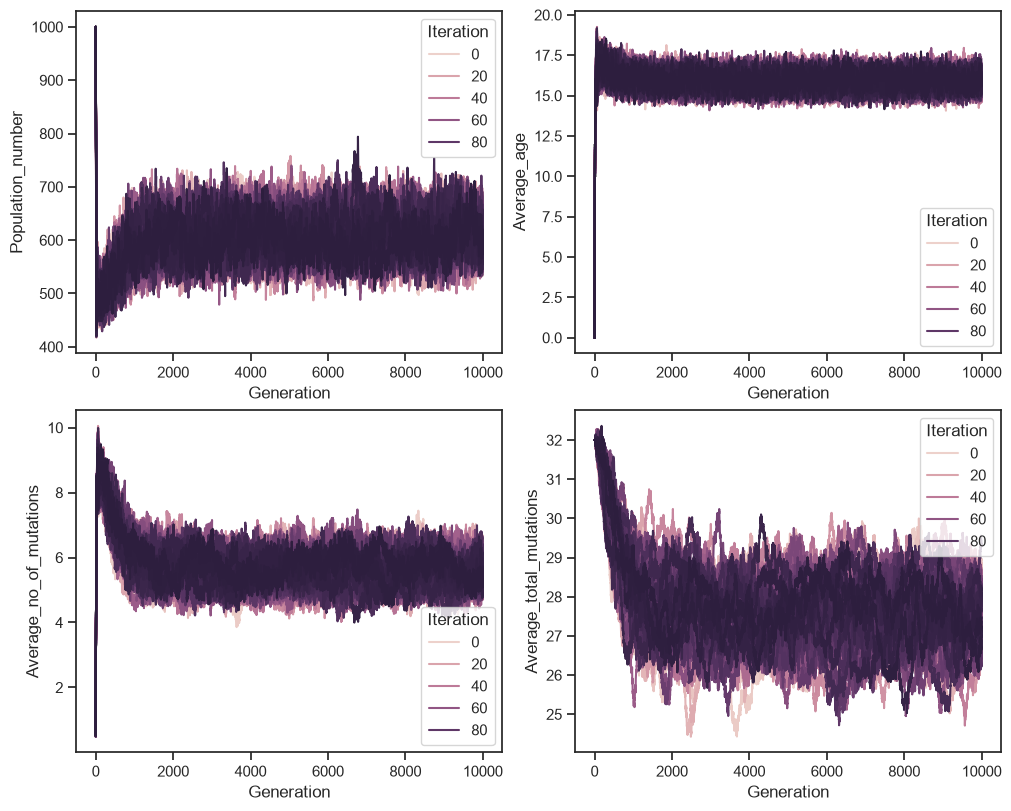

In [11]:
sns.set_style("ticks")

f, axes = plt.subplots(2, 2, figsize=(10, 8),constrained_layout=True)

sns.lineplot(
    data = df,
    x = 'Generation', y = 'Population_number', hue = 'Iteration',
    ax = axes[0,0]
)

sns.lineplot(
    data = df,
    x = 'Generation', y = 'Average_age', hue = 'Iteration',
    ax = axes[0,1]
)

sns.lineplot(
    data = df,
    x = 'Generation', y = 'Average_no_of_mutations', hue = 'Iteration',
    ax = axes[1,0]
)

sns.lineplot(
    data = df,
    x = 'Generation', y = 'Average_total_mutations', hue = 'Iteration',
    ax = axes[1,1]
)

<Axes: xlabel='Generation', ylabel='Average_total_mutations'>

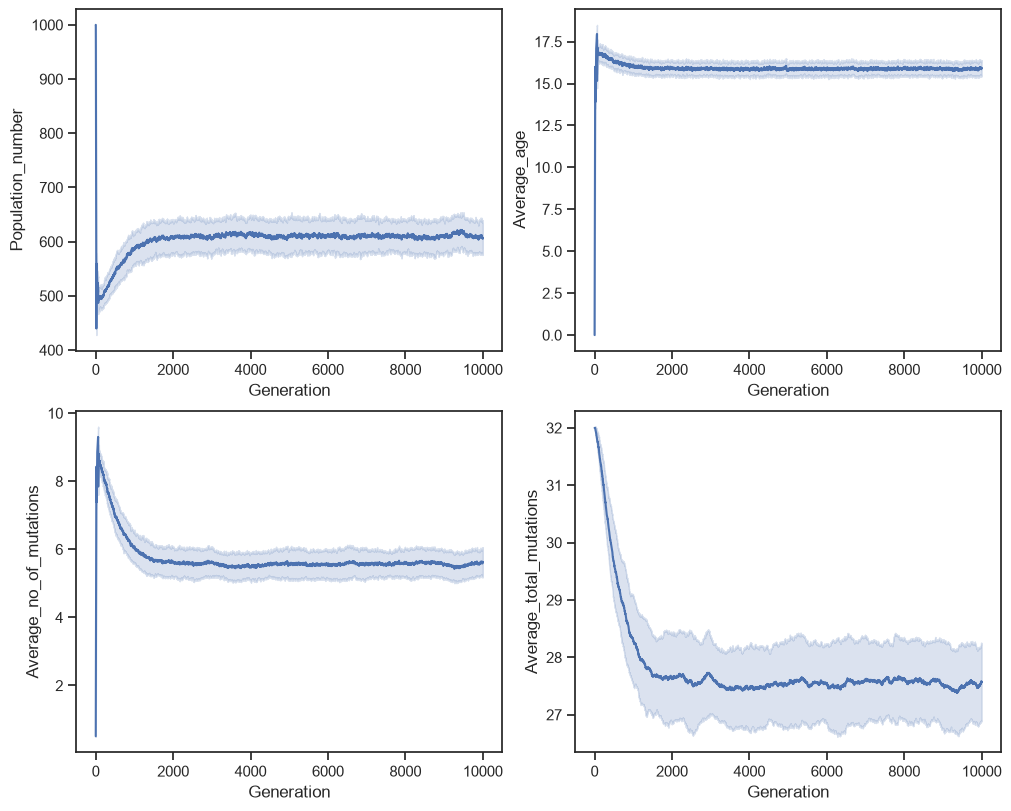

In [12]:
sns.set_style("ticks")

f, axes = plt.subplots(2, 2, figsize=(10, 8),constrained_layout=True)

sns.lineplot(
    data = df,
    x = 'Generation', y = 'Population_number', 
    errorbar='sd',
    ax = axes[0,0]
)

sns.lineplot(
    data = df,
    x = 'Generation', y = 'Average_age', 
    errorbar='sd',
    ax = axes[0,1]
)

sns.lineplot(
    data = df,
    x = 'Generation', y = 'Average_no_of_mutations', 
    errorbar='sd',
    ax = axes[1,0]
)

sns.lineplot(
    data = df,
    x = 'Generation', y = 'Average_total_mutations', 
    errorbar='sd',
    ax = axes[1,1]
)

## age and mutation dist. in final pop.

In [13]:
df_ages = df_ages_all[(df_ages_all['T'] == T) 
    & (df_ages_all['R'] == R)
    & (df_ages_all['br'] == br)]

df_suffered_mut = df_suffered_mut_all[(df_suffered_mut_all['T'] == T) 
    & (df_suffered_mut_all['R'] == R)
    & (df_suffered_mut_all['br'] == br)]

df_total_mut = df_total_mut_all[(df_total_mut_all['T'] == T) 
    & (df_total_mut_all['R'] == R)
    & (df_total_mut_all['br'] == br)]

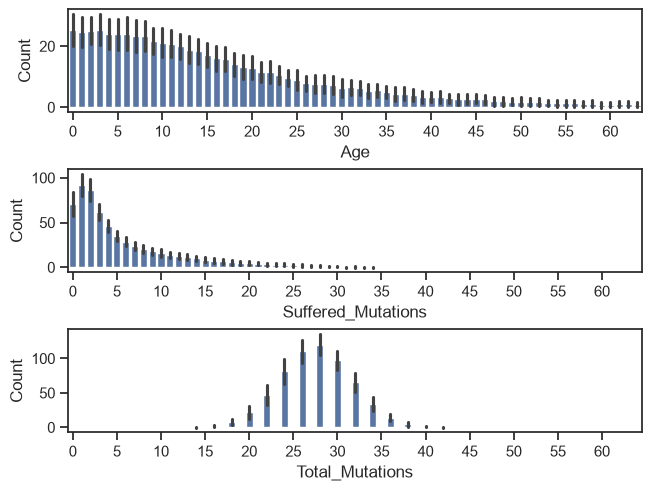

In [14]:
f, axes = plt.subplots(3,1,constrained_layout=True)
sns.barplot(data=df_ages, x='Age', y='Count', errorbar='sd', ax=axes[0])
sns.barplot(data=df_suffered_mut, x='Suffered_Mutations', y='Count', errorbar='sd', ax=axes[1])
sns.barplot(data=df_total_mut, x='Total_Mutations', y='Count', errorbar='sd', ax=axes[2])

for ax in axes:
    ax.set_xticks(ax.get_xticks()[::5])

# Vary mutation threshold T

In [15]:
param_sets = [runs[i][:-1] for i in [0,1,2]]

In [16]:
mask = df_all[['T', 'R', 'br']].apply(tuple, axis=1).isin(param_sets)
subset = df_all[mask].copy()

<Axes: xlabel='Generation', ylabel='Average_total_mutations'>

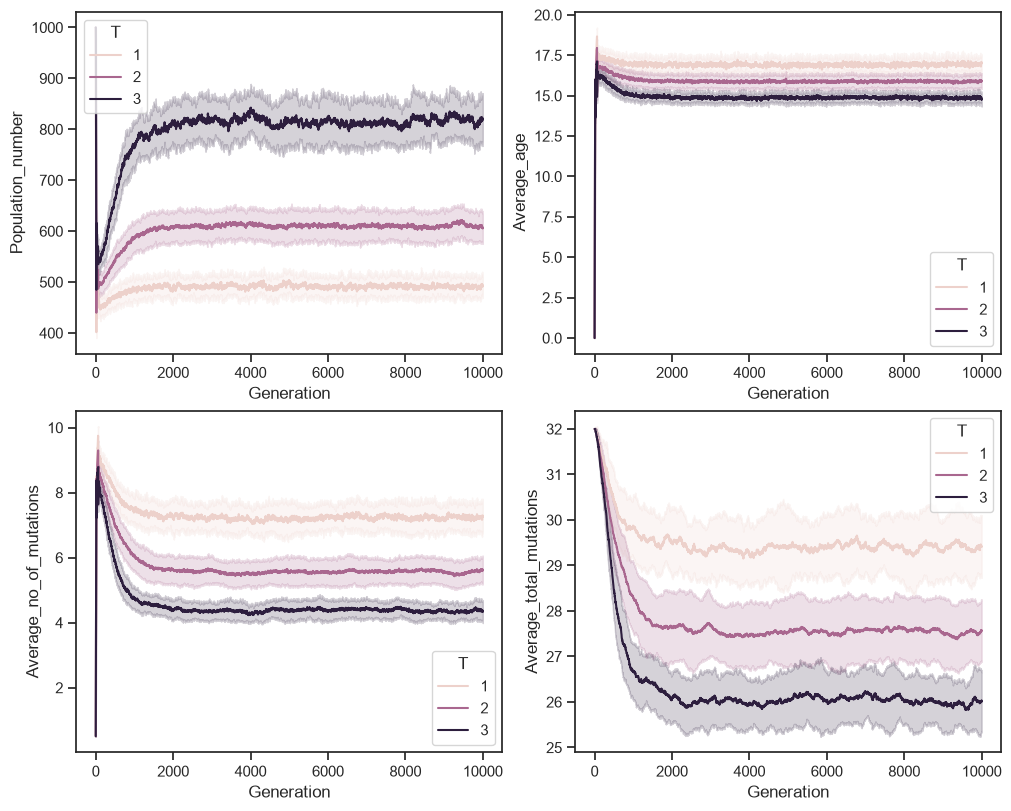

In [17]:
sns.set_style("ticks")

f, axes = plt.subplots(2, 2, figsize=(10, 8),constrained_layout=True)

sns.lineplot(
    data = subset,
    x = 'Generation', y = 'Population_number',
    hue = 'T',
    errorbar='sd',
    ax = axes[0,0]
)

sns.lineplot(
    data = subset,
    x = 'Generation', y = 'Average_age', 
    hue = 'T',
    errorbar='sd',
    ax = axes[0,1]
)

sns.lineplot(
    data = subset,
    x = 'Generation', y = 'Average_no_of_mutations', 
    hue = 'T',
    errorbar='sd',
    ax = axes[1,0]
)

sns.lineplot(
    data = subset,
    x = 'Generation', y = 'Average_total_mutations', 
    hue = 'T',
    errorbar='sd',
    ax = axes[1,1]
)

In [18]:
mask_ages = df_ages_all[['T', 'R', 'br']].apply(tuple, axis=1).isin(param_sets)
mask_suffered_mut = df_suffered_mut_all[['T', 'R', 'br']].apply(tuple, axis=1).isin(param_sets)
mask_total_mut = df_total_mut_all[['T', 'R', 'br']].apply(tuple, axis=1).isin(param_sets)

df_ages_subset = df_ages_all[mask_ages].copy()
df_suffered_mut_subset = df_suffered_mut_all[mask_suffered_mut].copy()
df_total_mut_subset = df_total_mut_all[mask_total_mut].copy()
df_total_mut_subset = df_total_mut_subset[df_total_mut_subset['Total_Mutations'] % 2 == 0]


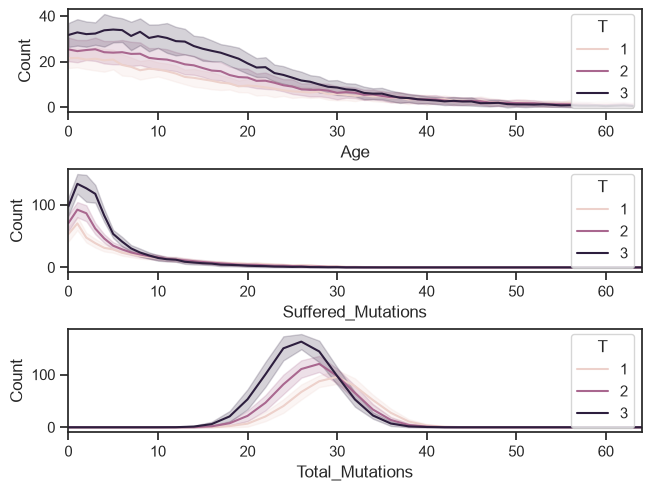

In [19]:
f, axes = plt.subplots(3,1,constrained_layout=True)
sns.lineplot(data=df_ages_subset, 
            x='Age', y='Count', 
            hue = 'T',
            errorbar='sd', ax=axes[0])
sns.lineplot(data=df_suffered_mut_subset, 
            x='Suffered_Mutations', y='Count', 
            hue = 'T',
            errorbar='sd', ax=axes[1])
sns.lineplot(data=df_total_mut_subset, 
            x='Total_Mutations', y='Count', 
            hue = 'T', 
            errorbar='sd', ax=axes[2])

for ax in axes:
    ax.set_xlim([0,64])
    sns.move_legend(ax, 'center right')

# Vary reproductive age R

In [20]:
param_sets = [runs[i][:-1] for i in [0,3,4]]

In [21]:
mask = df_all[['T', 'R', 'br']].apply(tuple, axis=1).isin(param_sets)
subset = df_all[mask].copy()

<Axes: xlabel='Generation', ylabel='Average_total_mutations'>

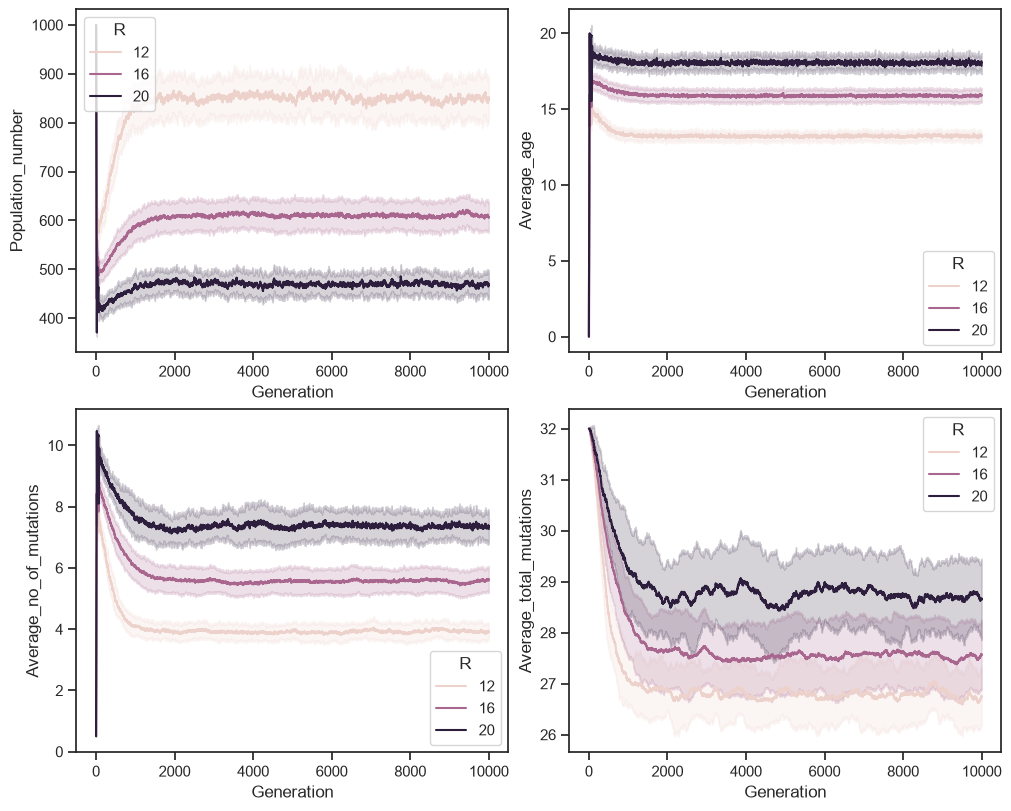

In [22]:
sns.set_style("ticks")

f, axes = plt.subplots(2, 2, figsize=(10, 8),constrained_layout=True)

sns.lineplot(
    data = subset,
    x = 'Generation', y = 'Population_number',
    hue = 'R',
    errorbar='sd',
    ax = axes[0,0]
)

sns.lineplot(
    data = subset,
    x = 'Generation', y = 'Average_age', 
    hue = 'R',
    errorbar='sd',
    ax = axes[0,1]
)

sns.lineplot(
    data = subset,
    x = 'Generation', y = 'Average_no_of_mutations', 
    hue = 'R',
    errorbar='sd',
    ax = axes[1,0]
)

sns.lineplot(
    data = subset,
    x = 'Generation', y = 'Average_total_mutations', 
    hue = 'R',
    errorbar='sd',
    ax = axes[1,1]
)

In [23]:
mask_ages = df_ages_all[['T', 'R', 'br']].apply(tuple, axis=1).isin(param_sets)
mask_suffered_mut = df_suffered_mut_all[['T', 'R', 'br']].apply(tuple, axis=1).isin(param_sets)
mask_total_mut = df_total_mut_all[['T', 'R', 'br']].apply(tuple, axis=1).isin(param_sets)

df_ages_subset = df_ages_all[mask_ages].copy()
df_suffered_mut_subset = df_suffered_mut_all[mask_suffered_mut].copy()
df_total_mut_subset = df_total_mut_all[mask_total_mut].copy()
df_total_mut_subset = df_total_mut_subset[df_total_mut_subset['Total_Mutations'] % 2 == 0]


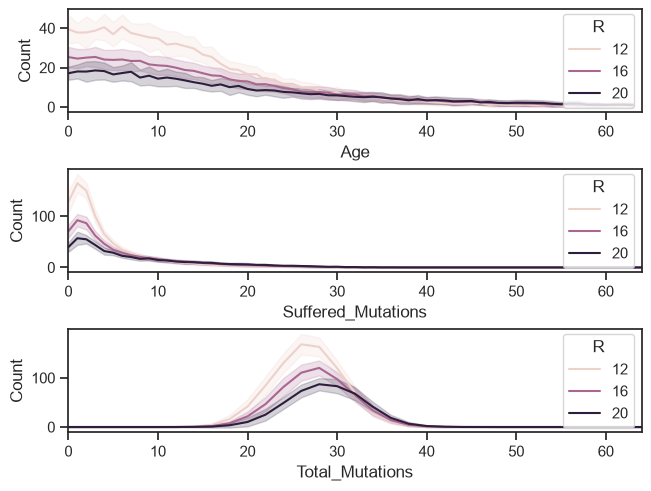

In [24]:
f, axes = plt.subplots(3,1,constrained_layout=True)
sns.lineplot(data=df_ages_subset, 
            x='Age', y='Count', 
            hue = 'R',
            errorbar='sd', ax=axes[0])
sns.lineplot(data=df_suffered_mut_subset, 
            x='Suffered_Mutations', y='Count', 
            hue = 'R',
            errorbar='sd', ax=axes[1])
sns.lineplot(data=df_total_mut_subset, 
            x='Total_Mutations', y='Count', 
            hue = 'R', 
            errorbar='sd', ax=axes[2])

for ax in axes:
    ax.set_xlim([0,64])
    sns.move_legend(ax, 'center right')

# Vary birth rate br

In [25]:
param_sets = [runs[i][:-1] for i in [0,5,6]]

In [26]:
mask = df_all[['T', 'R', 'br']].apply(tuple, axis=1).isin(param_sets)
subset = df_all[mask].copy()

<Axes: xlabel='Generation', ylabel='Average_total_mutations'>

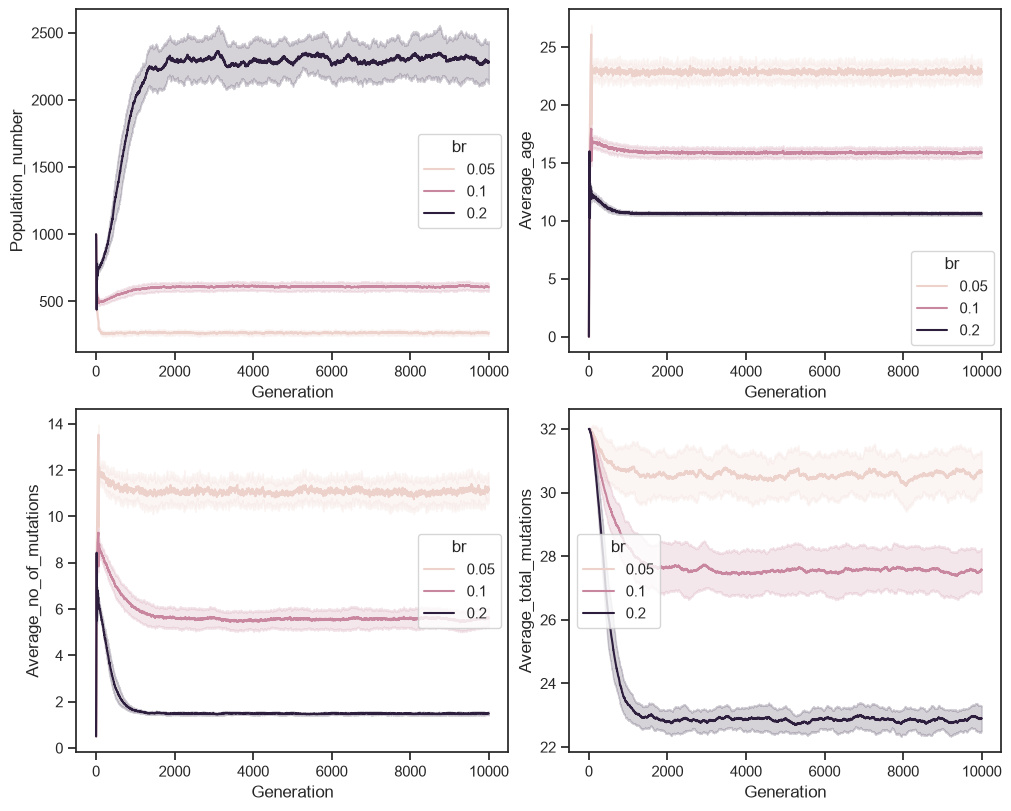

In [27]:
sns.set_style("ticks")

f, axes = plt.subplots(2, 2, figsize=(10, 8),constrained_layout=True)

sns.lineplot(
    data = subset,
    x = 'Generation', y = 'Population_number',
    hue = 'br',
    errorbar='sd',
    ax = axes[0,0]
)

sns.lineplot(
    data = subset,
    x = 'Generation', y = 'Average_age', 
    hue = 'br',
    errorbar='sd',
    ax = axes[0,1]
)

sns.lineplot(
    data = subset,
    x = 'Generation', y = 'Average_no_of_mutations', 
    hue = 'br',
    errorbar='sd',
    ax = axes[1,0]
)

sns.lineplot(
    data = subset,
    x = 'Generation', y = 'Average_total_mutations', 
    hue = 'br',
    errorbar='sd',
    ax = axes[1,1]
)

In [28]:
mask_ages = df_ages_all[['T', 'R', 'br']].apply(tuple, axis=1).isin(param_sets)
mask_suffered_mut = df_suffered_mut_all[['T', 'R', 'br']].apply(tuple, axis=1).isin(param_sets)
mask_total_mut = df_total_mut_all[['T', 'R', 'br']].apply(tuple, axis=1).isin(param_sets)

df_ages_subset = df_ages_all[mask_ages].copy()
df_suffered_mut_subset = df_suffered_mut_all[mask_suffered_mut].copy()
df_total_mut_subset = df_total_mut_all[mask_total_mut].copy()
df_total_mut_subset = df_total_mut_subset[df_total_mut_subset['Total_Mutations'] % 2 == 0]


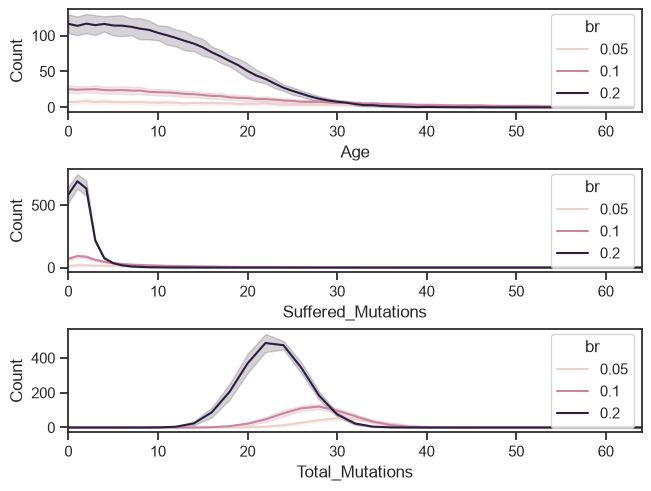

In [29]:
f, axes = plt.subplots(3,1,constrained_layout=True)
sns.lineplot(data=df_ages_subset, 
            x='Age', y='Count', 
            hue = 'br',
            errorbar='sd', ax=axes[0])
sns.lineplot(data=df_suffered_mut_subset, 
            x='Suffered_Mutations', y='Count', 
            hue = 'br',
            errorbar='sd', ax=axes[1])
sns.lineplot(data=df_total_mut_subset, 
            x='Total_Mutations', y='Count', 
            hue = 'br', 
            errorbar='sd', ax=axes[2])

for ax in axes:
    ax.set_xlim([0,64])
    sns.move_legend(ax, 'center right')